# IF3170 Artificial Intelligence | Tugas Besar 2

This notebook serves as a template for the assignment. Please create a copy of this notebook to complete your work. You can add more code blocks, markdown blocks, or new sections if needed.


Group Number: 33

Group Members:
- Stevan Einer Bonagabe (18223028)
- Hans Joseph B. W. S. (18223072)
- Jacob Reinhard Marudut S. (18223026)
- Muhammad Farhan (18223004)

## Import Libraries

In [357]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## Import Dataset

In [358]:
# Dataset lokal
data_train = pd.read_csv('train.csv')
data_test = pd.read_csv('test.csv')

print(f"Ukuran Data Training: {data_train.shape}")
print(f"Ukuran Data Testing: {data_test.shape}")

Ukuran Data Training: (100000, 31)
Ukuran Data Testing: (100000, 30)


# Exploratory Data Analysis (Optional)

Exploratory Data Analysis (EDA) is a crucial step in the data analysis process that involves examining and visualizing data sets to uncover patterns, trends, anomalies, and insights. It is the first step before applying more advanced statistical and machine learning techniques. EDA helps you to gain a deep understanding of the data you are working with, allowing you to make informed decisions and formulate hypotheses for further analysis.

In [359]:
print("ANALISIS DATA AWAL")

#  Sebaran Data Training
print("\n[TRAIN] 5 Baris Pertama:")
print(data_train.head())

print("\n[TRAIN] Info Dataset:")
print(data_train.info())

print("\n[TRAIN] Statistik Dasar:")
print(data_train.describe())

# Missing values
print("\n[TRAIN] Data Hilang per Kolom:")
missing_train = data_train.isnull().sum()
print(missing_train[missing_train > 0] if missing_train.sum() > 0 else "Tidak ada data hilang!")

# Cek duplikat
duplikat_train = data_train.duplicated().sum()
print(f"\n[TRAIN] Jumlah Baris Duplikat: {duplikat_train}")

# Distribusi target
print("\n[TRAIN] Distribusi Target:")
target_counts = data_train['is_fraud'].value_counts()
print(target_counts)
persen_fraud = 100 * target_counts[1] / len(data_train)
print(f"Persentase Fraud: {persen_fraud:.2f}%")

# Sebaran Data Testing
print("\n[TEST] 5 Baris Pertama:")
print(data_test.head())

print("\n[TEST] Info Dataset:")
print(data_test.info())

print("\n[TEST] Data Hilang per Kolom:")
missing_test = data_test.isnull().sum()
print(missing_test[missing_test > 0] if missing_test.sum() > 0 else "Tidak ada data hilang!")

# Perbandingan
print("\n PERBANDINGAN TRAIN VS TEST ")
print(f"Train: {len(data_train):,} baris, {data_train.shape[1]} kolom")
print(f"Test: {len(data_test):,} baris, {data_test.shape[1]} kolom")




print("EDA Selesai! Lanjut ke preprocessing...")


ANALISIS DATA AWAL

[TRAIN] 5 Baris Pertama:
   ID transaction_id  user_id  age gender country device_type device_os  \
0   0       T0065716    15307   35      M      UK      mobile   Android   
1   1       T0027857     1226   54      F      IN      mobile   Android   
2   2       T0055953    16072   35      M      US     desktop       iOS   
3   3       T0083660      725   23      F      US      mobile   Android   
4   4       T0017674     7367   32      M      UK      mobile   Android   

  merchant_category  transaction_amount  ... device_trust_score  \
0          clothing               17.70  ...              0.793   
1       restaurants                 NaN  ...                NaN   
2       restaurants                5.20  ...              0.281   
3       electronics              180.70  ...              0.061   
4               gas               35.45  ...              0.592   

   account_age_days  has_chargeback_history  shared_ip_users  \
0              1056                  

# 1. Split Training Set, Validation Set, Testing Set

Splitting the training and validation set works as an early diagnostic towards the performance of the model we train. This is done before the preprocessing steps to **avoid data leakage inbetween the sets**. If you want to use k-fold cross-validation, split the data later and do the cleaning and preprocessing separately for each split.

Note: For training, you should use the data contained in the `train` folder given by the TA. The `test` data is only used for kaggle submission.

In [360]:
print("\n SPLIT TRAIN/VALIDATION ")
target_column = 'is_fraud'

train_set, val_set = train_test_split(
    data_train, 
    test_size=0.2,
    random_state=42,
    stratify=data_train[target_column]
)

print(f"Train Set: {train_set.shape}")
print(f"Validation Set: {val_set.shape}")
print(f"Test Set (Kaggle): {data_test.shape}")


 SPLIT TRAIN/VALIDATION 
Train Set: (80000, 31)
Validation Set: (20000, 31)
Test Set (Kaggle): (100000, 30)


# 2. Data Cleaning and Preprocessing

This step is the first thing to be done once a Data Scientist have grasped a general knowledge of the data. Raw data is **seldom ready for training**, therefore steps need to be taken to clean and format the data for the Machine Learning model to interpret.

By performing data cleaning and preprocessing, you ensure that your dataset is ready for model training, leading to more accurate and reliable machine learning results. These steps are essential for transforming raw data into a format that machine learning algorithms can effectively learn from and make predictions.

We will give some common methods for you to try, but you only have to **at least implement one method for each process**. For each step that you will do, **please explain the reason why did you do that process. Write it in a markdown cell under the code cell you wrote.**

## A. Data Cleaning

**Data cleaning** is the crucial first step in preparing your dataset for machine learning. Raw data collected from various sources is often messy and may contain errors, missing values, and inconsistencies. Data cleaning involves the following steps:

1. **Handling Missing Data:** Identify and address missing values in the dataset. This can include imputing missing values, removing rows or columns with excessive missing data, or using more advanced techniques like interpolation.

2. **Dealing with Outliers:** Identify and handle outliers, which are data points significantly different from the rest of the dataset. Outliers can be removed or transformed to improve model performance.

3. **Data Validation:** Check for data integrity and consistency. Ensure that data types are correct, categorical variables have consistent labels, and numerical values fall within expected ranges.

4. **Removing Duplicates:** Identify and remove duplicate rows, as they can skew the model's training process and evaluation metrics.

5. **Feature Engineering**: Create new features or modify existing ones to extract relevant information. This step can involve scaling, normalizing, or encoding features for better model interpretability.

### I. Handling Missing Data

Missing data can adversely affect the performance and accuracy of machine learning models. There are several strategies to handle missing data in machine learning:

1. **Data Imputation:**

    a. **Mean, Median, or Mode Imputation:** For numerical features, you can replace missing values with the mean, median, or mode of the non-missing values in the same feature. This method is simple and often effective when data is missing at random.

    b. **Constant Value Imputation:** You can replace missing values with a predefined constant value (e.g., 0) if it makes sense for your dataset and problem.

    c. **Imputation Using Predictive Models:** More advanced techniques involve using predictive models to estimate missing values. For example, you can train a regression model to predict missing numerical values or a classification model to predict missing categorical values.

2. **Deletion of Missing Data:**

    a. **Listwise Deletion:** In cases where the amount of missing data is relatively small, you can simply remove rows with missing values from your dataset. However, this approach can lead to a loss of valuable information.

    b. **Column (Feature) Deletion:** If a feature has a large number of missing values and is not critical for your analysis, you can consider removing that feature altogether.

3. **Domain-Specific Strategies:**

    a. **Domain Knowledge:** In some cases, domain knowledge can guide the imputation process. For example, if you know that missing values are related to a specific condition, you can impute them accordingly.

4. **Imputation Libraries:**

    a. **Scikit-Learn:** Scikit-Learn provides a `SimpleImputer` class that can handle basic imputation strategies like mean, median, and mode imputation.

    b. **Fancyimpute:** Fancyimpute is a Python library that offers more advanced imputation techniques, including matrix factorization, k-nearest neighbors, and deep learning-based methods.

The choice of imputation method should be guided by the nature of your data, the amount of missing data, the problem you are trying to solve, and the assumptions you are willing to make.

In [361]:
# FUNGSI: IMPUTASI (MISSING VALUES)

def impute_missing_values(data):
    data = data.copy()
    
    # Identifikasi kolom numerik dan kategorikal
    kolom_numeric = data.select_dtypes(include=['number']).columns.tolist()
    # Buang target jika ada
    if 'is_fraud' in kolom_numeric:
        kolom_numeric.remove('is_fraud')
    
    kolom_categorical = data.select_dtypes(include=['object']).columns.tolist()
    
    print(f"Imputasi - Kolom Numerik: {len(kolom_numeric)}, Kategorikal: {len(kolom_categorical)}")
    
    # Imputasi Numerik dengan MEDIAN
    for kolom in kolom_numeric:
        if kolom in data.columns:
            median_val = data[kolom].median()
            data[kolom] = data[kolom].fillna(median_val)
    
    # Imputasi Kategorikal dengan MODUS
    for kolom in kolom_categorical:
        if kolom in data.columns:
            if not data[kolom].mode().empty:
                mode_val = data[kolom].mode().iloc[0]
                data[kolom] = data[kolom].fillna(mode_val)
            else:
                data[kolom] = data[kolom].fillna("Unknown")
    
    print(f"Sisa NaN setelah imputasi: {data.isnull().sum().sum()}")
    
    return data

### II. Dealing with Outliers

Outliers are data points that significantly differ from the majority of the data. They can be unusually high or low values that do not fit the pattern of the rest of the dataset. Outliers can significantly impact model performance, so it is important to handle them properly.

Some methods to handle outliers:
1. **Imputation**: Replace with mean, median, or a boundary value.
2. **Clipping**: Cap values to upper and lower limits.
3. **Transformation**: Use log, square root, or power transformations to reduce their influence.
4. **Model-Based**: Use algorithms robust to outliers (e.g., tree-based models, Huber regression).

In [362]:

# FUNGSI: HANDLING OUTLIERS


def clip_outliers(data, lower_percentile=0.01, upper_percentile=0.99):
   
    data = data.copy()
    
    # Identifikasi kolom numerik
    kolom_numeric = data.select_dtypes(include=['number']).columns.tolist()
    if 'is_fraud' in kolom_numeric:
        kolom_numeric.remove('is_fraud')
    
    print(f"Clipping {len(kolom_numeric)} kolom (Persentil {lower_percentile*100}%-{upper_percentile*100}%)...")
    
    for kolom in kolom_numeric:
        if kolom in data.columns:
            lower_limit = data[kolom].quantile(lower_percentile)
            upper_limit = data[kolom].quantile(upper_percentile)
            data[kolom] = data[kolom].clip(lower_limit, upper_limit)
    
    print("✓ Clipping selesai")
    
    return data

### III. Remove Duplicates
Handling duplicate values is crucial because they can compromise data integrity, leading to inaccurate analysis and insights. Duplicate entries can bias machine learning models, causing overfitting and reducing their ability to generalize to new data. They also inflate the dataset size unnecessarily, increasing computational costs and processing times. Additionally, duplicates can distort statistical measures and lead to inconsistencies, ultimately affecting the reliability of data-driven decisions and reporting. Ensuring data quality by removing duplicates is essential for accurate, efficient, and consistent analysis.

In [363]:
# FUNGSI: PENGECEKAN DUPLIKAT (3 LAPIS)

def remove_duplicates(data):
    data = data.copy()
    initial_rows = data.shape[0]
    
    print(f"Jumlah baris awal: {initial_rows}")
    
    # LAPIS 1: Cek ID
    if 'ID' in data.columns:
        dup_id = data.duplicated(subset=['ID']).sum()
        if dup_id > 0:
            print(f"ID duplikat: {dup_id}")
            data = data.drop_duplicates(subset=['ID'], keep='first')
        
        data = data.drop(columns=['ID'], errors='ignore')
        print("ID diperiksa & dihapus")
    
    # LAPIS 2: Cek transaction_id
    if 'transaction_id' in data.columns:
        dup_tid = data.duplicated(subset=['transaction_id']).sum()
        if dup_tid > 0:
            print(f"Transaction_id duplikat: {dup_tid}")
            data = data.drop_duplicates(subset=['transaction_id'], keep='first')
        
        data = data.drop(columns=['transaction_id'], errors='ignore')
        print("Transaction_id diperiksa & dihapus")
    
    # LAPIS 3: Cek konten duplikat
    dup_content = data.duplicated().sum()
    if dup_content > 0:
        print(f"[Lapis 3] Konten duplikat: {dup_content}")
        data = data.drop_duplicates(keep='first')
    else:
        print("Tidak ada duplikat konten")
    
    final_rows = data.shape[0]
    print(f"✓ Total dihapus: {initial_rows - final_rows}")
    
    return data

### IV. Feature Engineering

**Feature engineering** involves creating new features (input variables) or transforming existing ones to improve the performance of machine learning models. Feature engineering aims to enhance the model's ability to learn patterns and make accurate predictions from the data. It's often said that "good features make good models."

1. **Feature Selection:** Feature engineering can involve selecting the most relevant and informative features from the dataset. Removing irrelevant or redundant features not only simplifies the model but also reduces the risk of overfitting.

2. **Creating New Features:** Sometimes, the existing features may not capture the underlying patterns effectively. In such cases, engineers create new features that provide additional information. For example:
   
   - **Polynomial Features:** Engineers may create new features by taking the square, cube, or other higher-order terms of existing numerical features. This can help capture nonlinear relationships.
   
   - **Interaction Features:** Interaction features are created by combining two or more existing features. For example, if you have features "length" and "width," you can create an "area" feature by multiplying them.

3. **Binning or Discretization:** Continuous numerical features can be divided into bins or categories. For instance, age values can be grouped into bins like "child," "adult," and "senior."

4. **Domain-Specific Feature Engineering:** Depending on the domain and problem, engineers may create domain-specific features. For example, in fraud detection, features related to transaction history and user behavior may be engineered to identify anomalies.

Feature engineering is both a creative and iterative process. It requires a deep understanding of the data, domain knowledge, and experimentation to determine which features will enhance the model's predictive power.

In [364]:

# FUNGSI: FEATURE ENGINEERING

def create_features(data):
    data = data.copy()
    
    print("Membuat Interaction Features...")
    # Rasio dan gabungan
    data['amount_ratio'] = data['transaction_amount'] / (data['avg_transaction_amount'] + 0.001)
    data['velocity_ratio'] = data['transactions_last_1h'] / (data['transactions_last_24h'] + 0.001)
    data['total_external_risk'] = data['ip_risk_score'] + data['merchant_risk'] + data['country_risk']
    data['device_security_flag'] = (data['ip_risk_score'] + (1 - data['device_trust_score'])) / 2
    
    print("Membuat Binning Features...")
    # Age Group
    labels_age = ['Young', 'Adult', 'Senior']
    bins_age = [0, 25, 60, 150]
    data['age_group'] = pd.cut(data['age'], bins=bins_age, labels=labels_age)
    
    # Time Periode
    labels_time = ['Night', 'Morning', 'Afternoon', 'Evening']
    bins_time = [-1, 6, 12, 18, 24]
    data['time_period'] = pd.cut(data['time_of_day'], bins=bins_time, labels=labels_time)
    
    print("Membuat Behavioral Features...")
    # Behavioral anomaly
    data['suspicious_login'] = (data['failed_login_attempts'] > 2).astype(int)
    data['is_weekend'] = data['day_of_week'].isin([5, 6]).astype(int)
    
    print("Feature Engineering selesai")
    
    return data

## B. Data Preprocessing

**Data preprocessing** is a broader step that encompasses both data cleaning and additional transformations to make the data suitable for machine learning algorithms. Its primary goals are:

1. **Feature Scaling:** Ensure that numerical features have similar scales. Common techniques include Min-Max scaling (scaling to a specific range) or standardization (mean-centered, unit variance).

2. **Encoding Categorical Variables:** Machine learning models typically work with numerical data, so categorical variables need to be encoded. This can be done using one-hot encoding, label encoding, or more advanced methods like target encoding.

3. **Handling Imbalanced Classes:** If dealing with imbalanced classes in a binary classification task, apply techniques such as oversampling, undersampling, or using different evaluation metrics to address class imbalance.

4. **Dimensionality Reduction:** Reduce the number of features using techniques like Principal Component Analysis (PCA) or feature selection to simplify the model and potentially improve its performance.

5. **Normalization:** Normalize data to achieve a standard distribution. This is particularly important for algorithms that assume normally distributed data.

### Notes on Preprocessing processes

It is advised to create functions or classes that have the same/similar type of inputs and outputs, so you can add, remove, or swap the order of the processes easily. You can implement the functions or classes by yourself

or

use `sklearn` library. To create a new preprocessing component in `sklearn`, implement a corresponding class that includes:
1. Inheritance to `BaseEstimator` and `TransformerMixin`
2. The method `fit`
3. The method `transform`

In [365]:
from sklearn.base import BaseEstimator, TransformerMixin

class ColumnDropper(BaseEstimator, TransformerMixin):
    def __init__(self, cols_to_drop):
        self.cols_to_drop = cols_to_drop

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_dropped = X.copy()
        
        X_dropped = X_dropped.drop(self.cols_to_drop, axis=1, errors='ignore')
        
        return X_dropped

### I. Feature Scaling

**Feature scaling** is a preprocessing technique used in machine learning to standardize the range of independent variables or features of data. The primary goal of feature scaling is to ensure that all features contribute equally to the training process and that machine learning algorithms can work effectively with the data.

Here are the main reasons why feature scaling is important:

1. **Algorithm Sensitivity:** Many machine learning algorithms are sensitive to the scale of input features. If the scales of features are significantly different, some algorithms may perform poorly or take much longer to converge.

2. **Distance-Based Algorithms:** Algorithms that rely on distances or similarities between data points, such as k-nearest neighbors (KNN) and support vector machines (SVM), can be influenced by feature scales. Features with larger scales may dominate the distance calculations.

3. **Regularization:** Regularization techniques, like L1 (Lasso) and L2 (Ridge) regularization, add penalty terms based on feature coefficients. Scaling ensures that all features are treated equally in the regularization process.

Common methods for feature scaling include:

1. **Min-Max Scaling (Normalization):** This method scales features to a specific range, typically [0, 1]. It's done using the following formula:

   $$X' = \frac{X - X_{min}}{X_{max} - X_{min}}$$

   - Here, $X$ is the original feature value, $X_{min}$ is the minimum value of the feature, and $X_{max}$ is the maximum value of the feature.  
<br />
<br />
2. **Standardization (Z-score Scaling):** This method scales features to have a mean (average) of 0 and a standard deviation of 1. It's done using the following formula:

   $$X' = \frac{X - \mu}{\sigma}$$

   - $X$ is the original feature value, $\mu$ is the mean of the feature, and $\sigma$ is the standard deviation of the feature.  
<br />
<br />
3. **Robust Scaling:** Robust scaling is a method that scales features to the interquartile range (IQR) and is less affected by outliers. It's calculated as:

   $$X' = \frac{X - Q1}{Q3 - Q1}$$

   - $X$ is the original feature value, $Q1$ is the first quartile (25th percentile), and $Q3$ is the third quartile (75th percentile) of the feature.  
<br />
<br />
4. **Log Transformation:** In cases where data is highly skewed or has a heavy-tailed distribution, taking the logarithm of the feature values can help stabilize the variance and improve scaling.

The choice of scaling method depends on the characteristics of your data and the requirements of your machine learning algorithm. **Min-max scaling and standardization are the most commonly used techniques and work well for many datasets.**

Scaling should be applied separately to each training and test set to prevent data leakage from the test set into the training set. Additionally, **some algorithms may not require feature scaling, particularly tree-based models.**

In [366]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
import numpy as np

class FeatureScaler(BaseEstimator, TransformerMixin):
    def __init__(self, cols_to_scale, scaler_type='minmax'):
        """
        Custom Scaler :
        1. MinMax (Normalization) -> Bagus untuk KNN
        2. Standard (Standardization) -> Bagus untuk Logistic Regression
        3. Robust -> Bagus jika banyak Outlier
        4. Log -> Bagus untuk data skewed timpang seperti Transaction Amount
        
        Parameters:
        -----------
        cols_to_scale : list
            Daftar nama kolom yang ingin di-scaling.
        scaler_type : str
            Pilihan: 'minmax', 'standard', 'robust', atau 'log'.
        """
        self.cols_to_scale = cols_to_scale
        self.scaler_type = scaler_type
        self.scaler = None

    def fit(self, X, y=None):
        # Log Transformation tidak butuh fit karna nggak perlu menghitung rata-rata dulu
        if self.scaler_type == 'log':
            return self

        # Memilih scaler untuk 3 metode lainnya
        if self.scaler_type == 'minmax':
            self.scaler = MinMaxScaler()
        elif self.scaler_type == 'standard':
            self.scaler = StandardScaler()
        elif self.scaler_type == 'robust':
            self.scaler = RobustScaler()
        else:
            # Default fallback
            self.scaler = MinMaxScaler()

        # Fit hanya pada kolom yang dipilih
        if self.cols_to_scale:
            self.scaler.fit(X[self.cols_to_scale])
            
        return self

    def transform(self, X):
        X_scaled = X.copy()
        
        # Pastikan ada kolom yang mau diubah
        if self.cols_to_scale:
            
            # Khusus Log Transformation
            if self.scaler_type == 'log':
                # Menggunakan np.log1p (log(1+x)) biar aman kalau ada angka 0
                # terapkan hanya ke kolom yang dipilih
                X_scaled[self.cols_to_scale] = np.log1p(X_scaled[self.cols_to_scale])
            
            # Logic untuk Scaler biasa (MinMax, Standard, Robust)
            else:
                X_scaled[self.cols_to_scale] = self.scaler.transform(X[self.cols_to_scale])
        
        return X_scaled

### II. Feature Encoding

**Feature encoding**, also known as **categorical encoding**, is the process of converting categorical data (non-numeric data) into a numerical format so that it can be used as input for machine learning algorithms. Most machine learning models require numerical data for training and prediction, so feature encoding is a critical step in data preprocessing.

Categorical data can take various forms, including:

1. **Nominal Data:** Categories with no intrinsic order, like colors or country names.  

2. **Ordinal Data:** Categories with a meaningful order but not necessarily equidistant, like education levels (e.g., "high school," "bachelor's," "master's").

There are several common methods for encoding categorical data:

1. **Label Encoding:**

   - Label encoding assigns a unique integer to each category in a feature.
   - It's suitable for ordinal data where there's a clear order among categories.
   - For example, if you have an "education" feature with values "high school," "bachelor's," and "master's," you can encode them as 0, 1, and 2, respectively.
<br />
<br />
2. **One-Hot Encoding:**

   - One-hot encoding creates a binary (0 or 1) column for each category in a nominal feature.
   - It's suitable for nominal data where there's no inherent order among categories.
   - Each category becomes a new feature, and the presence (1) or absence (0) of a category is indicated for each row.
<br />
<br />
3. **Target Encoding (Mean Encoding):**

   - Target encoding replaces each category with the mean of the target variable for that category.
   - It's often used for classification problems.

In [367]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
import pandas as pd
import numpy as np

class FeatureEncoder(BaseEstimator, TransformerMixin):
    def __init__(self, cols_to_encode, encoding_type='onehot'):
        """
        Custom Encoder :
        1. label    : Mengubah kategori jadi angka urut (0, 1, 2...)
        2. onehot   : Membuat kolom biner 0/1 untuk tiap kategori
        3. target   : Mengubah kategori jadi rata-rata target (Mean Encoding)
        
        Parameters:
        -----------
        cols_to_encode : list
            Daftar kolom yang akan di-encode.
        encoding_type : str
            Pilihan: 'label', 'onehot', atau 'target'.
        """
        self.cols_to_encode = cols_to_encode
        self.encoding_type = encoding_type
        
        # Variabel untuk menyimpan kamus encoding
        self.encoder = None 
        self.target_means = {}  # Khusus untuk Target Encoding
        self.global_mean = 0    # Default jika ada kategori baru di target encoding

    def fit(self, X, y=None):
        # 1. Label Encoding
        if self.encoding_type == 'label':
            # Kita gunakan OrdinalEncoder dari sklearn (fungsinya sama dengan Label Encoding untuk fitur)
            # handle_unknown='use_encoded_value' agar aman jika ada data asing di test set
            self.encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
            self.encoder.fit(X[self.cols_to_encode])
            
        # 2. One-Hot Encoding
        elif self.encoding_type == 'onehot':
            self.encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
            self.encoder.fit(X[self.cols_to_encode])
            
        # 3. Target Encoding (Mean Encoding)
        elif self.encoding_type == 'target':
            if y is None:
                raise ValueError("Metode 'target' encoding WAJIB menyertakan parameter y (label) saat fit!")
            
            # Hitung rata-rata global (jaga-jaga untuk data baru)
            self.global_mean = y.mean()
            
            # Gabungkan X dan y sementara untuk hitung rata-rata
            temp_df = X.copy()
            temp_df['target'] = y
            
            for col in self.cols_to_encode:
                # Hitung rata-rata target per kategori
                means = temp_df.groupby(col)['target'].mean()
                self.target_means[col] = means
                
        return self

    def transform(self, X):
        X_encoded = X.copy()
        
        # 1. Proses Label Encoding
        if self.encoding_type == 'label':
            X_encoded[self.cols_to_encode] = self.encoder.transform(X[self.cols_to_encode])
            
        # 2. Proses One-Hot Encoding
        elif self.encoding_type == 'onehot':
            ohe_results = self.encoder.transform(X[self.cols_to_encode])
            feature_names = self.encoder.get_feature_names_out(self.cols_to_encode)
            ohe_df = pd.DataFrame(ohe_results, columns=feature_names, index=X.index)
            
            # Gabung dan buang kolom lama
            X_encoded = pd.concat([X_encoded, ohe_df], axis=1)
            X_encoded.drop(columns=self.cols_to_encode, inplace=True)
            
        # 3. Proses Target Encoding
        elif self.encoding_type == 'target':
            for col in self.cols_to_encode:
                # Map nilai kategori ke angka rata-ratanya
                # Jika ada kategori baru (NaN), isi dengan rata-rata global
                X_encoded[col] = X_encoded[col].map(self.target_means[col]).fillna(self.global_mean)
                
        return X_encoded

### III. Handling Imbalanced Dataset

**Handling imbalanced datasets** is important because imbalanced data can lead to several issues that negatively impact the performance and reliability of machine learning models. Here are some key reasons:

1. **Biased Model Performance**:

 - Models trained on imbalanced data tend to be biased towards the majority class, leading to poor performance on the minority class. This can result in misleading accuracy metrics.

2. **Misleading Accuracy**:

 - High overall accuracy can be misleading in imbalanced datasets. For example, if 95% of the data belongs to one class, a model that always predicts the majority class will have 95% accuracy but will fail to identify the minority class.

3. **Poor Generalization**:

 - Models trained on imbalanced data may not generalize well to new, unseen data, especially if the minority class is underrepresented.


Some methods to handle imbalanced datasets:
1. **Resampling Methods**:

 - Oversampling: Increase the number of instances in the minority class by duplicating or generating synthetic samples (e.g., SMOTE).
 - Undersampling: Reduce the number of instances in the majority class to balance the dataset.

2. **Evaluation Metrics**:

 - Use appropriate evaluation metrics such as precision, recall, F1-score, ROC-AUC, and confusion matrix instead of accuracy to better assess model performance on imbalanced data.

3. **Algorithmic Approaches**:

 - Use algorithms that are designed to handle imbalanced data, such as decision trees, random forests, or ensemble methods.
 - Adjust class weights in algorithms to give more importance to the minority class.

In [368]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
import pandas as pd
import numpy as np

class ImbalanceHandler(BaseEstimator, TransformerMixin):
    def __init__(self, method='smote', random_state=42):
        """
        Class untuk menangani Imbalance Dataset:
          - 'smote' -> Generate synthetic samples (recommended)
          - 'random_oversampling' -> Duplicate minority class
          - 'random_undersampling' -> Downsample majority class
        """
        self.method = method
        self.random_state = random_state

    def fit(self, X, y=None):
        return self

    def transform(self, X, y):
        # 1. Jika method SMOTE, gunakan library imblearn langsung
        # Ini menghandle input baik berupa DataFrame maupun Numpy Array
        if self.method == 'smote':
            smote = SMOTE(random_state=self.random_state)
            X_res, y_res = smote.fit_resample(X, y)
            return X_res, y_res

        # 2. Jika method Manual (Random Over/Under Sampling)
        # Kita perlu menggabungkan X dan y sementara
        if isinstance(X, pd.DataFrame):
            data = X.copy()
        else:
            # Jika input dari Pipeline berupa Numpy Array (misal hasil PCA), ubah ke DF
            data = pd.DataFrame(X)
            
        # Pastikan y berupa array untuk assignment
        y_vals = y.values if isinstance(y, pd.Series) else y
        data['target_temp_label'] = y_vals

        majority = data[data['target_temp_label'] == 0]
        minority = data[data['target_temp_label'] == 1]

        if self.method == 'random_oversampling':
            minority_upsampled = resample(
                minority,
                replace=True,
                n_samples=len(majority),
                random_state=self.random_state
            )
            data_resampled = pd.concat([majority, minority_upsampled])

        elif self.method == 'random_undersampling':
            majority_downsampled = resample(
                majority,
                replace=False,
                n_samples=len(minority),
                random_state=self.random_state
            )
            data_resampled = pd.concat([majority_downsampled, minority])

        else:
            return X, y

        # Pisahkan kembali
        y_resampled = data_resampled['target_temp_label']
        X_resampled = data_resampled.drop('target_temp_label', axis=1)

        # Kembalikan ke format numpy jika input awalnya numpy
        if not isinstance(X, pd.DataFrame):
            return X_resampled.values, y_resampled.values
            
        return X_resampled, y_resampled

print("Class ImbalanceHandler udah ada ya")

Class ImbalanceHandler udah ada ya


### IV. Data Normalization

Data normalization is used to achieve a standard distribution. Without normalization, models or processes that rely on the assumption of normality may not work correctly. Normalization helps reduce the magnitude effect and ensures numerical stability during optimization.

In [369]:
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler

class DataNormalizer(BaseEstimator, TransformerMixin):
    def __init__(self, cols_to_normalize):
        """
        Class untuk Data Normalization (Standardization / Z-Score).
        Tujuannya: Membuat distribusi data memiliki Mean=0 dan Std=1.
        
        Parameters:
        -----------
        cols_to_normalize : list
            Daftar nama kolom numerik yang akan di-standarisasi.
        """
        self.cols_to_normalize = cols_to_normalize
        self.scaler = StandardScaler()

    def fit(self, X, y=None):
        # Mesin belajar Rata-rata (Mean) dan Standar Deviasi dari data train
        if self.cols_to_normalize:
            self.scaler.fit(X[self.cols_to_normalize])
        return self

    def transform(self, X):
        X_norm = X.copy()
        
        # Terapkan rumus Z-Score: z = (x - mean) / std_dev
        if self.cols_to_normalize:
            X_norm[self.cols_to_normalize] = self.scaler.transform(X[self.cols_to_normalize])
            
        return X_norm

### V. Dimensionality Reduction

Dimensionality reduction is a technique used in data preprocessing to reduce the number of input features (dimensions) in a dataset while retaining as much important information as possible. It is essential when dealing with high-dimensional data, where too many features can cause problems like increased computational costs, overfitting, and difficulty in visualization. Reducing dimensions simplifies the data, making it easier to analyze and improving the performance of machine learning models.

One of the main approaches to dimensionality reduction is feature extraction. Feature extraction creates new, smaller sets of features that capture the essence of the original data. Common techniques include:

1. **Principal Component Analysis (PCA)**: Converts correlated features into a smaller number of uncorrelated "principal components."
2. **t-SNE (t-Distributed Stochastic Neighbor Embedding)**: A visualization-focused method to project high-dimensional data into 2D or 3D spaces.
3. **Autoencoders**: Neural networks that learn compressed representations of the data.

In [370]:
# Dimensionality Reduction (PCA) hanya definisi kelas
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA

class DimensionalityReducer(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=None):
        """
        Reduksi dimensi menggunakan PCA.
        n_components:
          - None  : pass-through (tidak mengubah data)
          - int   : jumlah komponen PCA
          - float : proporsi varian yang dipertahankan (mis. 0.95)
        """
        self.n_components = n_components
        self.pca = None

    def fit(self, X, y=None):
        if self.n_components is None:
            return self
        self.pca = PCA(n_components=self.n_components)
        self.pca.fit(X)
        return self

    def transform(self, X):
        if self.n_components is None or self.pca is None:
            return X
        return self.pca.transform(X)

# 3. Compile Preprocessing Pipeline

All of the preprocessing classes or functions defined earlier will be compiled in this step.

If you use sklearn to create preprocessing classes, you can list your preprocessing classes in the Pipeline object sequentially, and then fit and transform your data.

In [371]:
# Pastikan kelas imputer tersedia sebelum menyusun pipeline
try:
    _ = DataFrameImputer
except NameError:
    from sklearn.base import BaseEstimator, TransformerMixin
    import pandas as pd

    class DataFrameImputer(BaseEstimator, TransformerMixin):
        def __init__(self, unknown_fill="Unknown"):
            self.unknown_fill = unknown_fill
            self.num_medians_ = {}
            self.cat_modes_ = {}
            self.num_cols_ = []
            self.cat_cols_ = []

        def fit(self, X, y=None):
            df = X.copy()
            self.num_cols_ = df.select_dtypes(include=['number']).columns.tolist()
            self.cat_cols_ = df.select_dtypes(exclude=['number']).columns.tolist()
            # Simpan statistik sederhana dari train untuk dipakai saat transform
            for c in self.num_cols_:
                self.num_medians_[c] = df[c].median()
            for c in self.cat_cols_:
                mode_series = df[c].mode(dropna=True)
                self.cat_modes_[c] = mode_series.iloc[0] if not mode_series.empty else self.unknown_fill
            return self

        def transform(self, X):
            df = X.copy()
            # Isi nilai kosong numerik dengan median dan kategori dengan modus/Unknown
            for c in self.num_cols_:
                if c in df.columns:
                    df[c] = df[c].fillna(self.num_medians_[c])
            for c in self.cat_cols_:
                if c in df.columns:
                    df[c] = df[c].fillna(self.cat_modes_[c])
            return df

In [372]:
from sklearn.pipeline import Pipeline

# Kolom acuan dari train (aman: nanti difilter terhadap yang tersedia)
cols_drop = ['ID', 'transaction_id', 'user_id']

# Kategori dengan sedikit nilai unik → One-Hot
cols_onehot = ['gender', 'device_type', 'transaction_type', 'day_of_week', 'is_new_country']

# Kategori dengan banyak nilai unik → Target/Frequency encoding
cols_target_enc = ['merchant_category', 'country', 'device_os']

# Fitur numerik yang akan dinormalisasi/ditransform
cols_norm = [
    'age', 'transaction_amount', 'time_of_day', 'transaction_duration',
    'num_prev_transactions', 'avg_transaction_amount', 'std_transaction_amount',
    'transactions_last_24h', 'transactions_last_1h', 'failed_login_attempts',
    'ip_risk_score', 'device_trust_score', 'account_age_days',
    'shared_ip_users', 'shared_device_users', 'merchant_risk', 'country_risk',
    'distance_from_home'
 ]

# Fitur yang sangat skewed → pakai log1p
cols_log = ['transaction_amount', 'distance_from_home']

# Filter kolom yang benar-benar ada setelah menghapus target & ID
target_col = 'is_fraud'
available_after_drop = [c for c in data_train.columns if c not in set(cols_drop + [target_col])]
cols_onehot_safe = [c for c in cols_onehot if c in available_after_drop]
cols_target_enc_safe = [c for c in cols_target_enc if c in available_after_drop]
cols_norm_safe = [c for c in cols_norm if c in available_after_drop]
cols_log_safe = [c for c in cols_log if c in available_after_drop]

print('[Preprocessing] Kolom yang dipakai:')
print(f"  Drop        : {cols_drop}")
print(f"  One-Hot     : {cols_onehot_safe}")
print(f"  Target Enc  : {cols_target_enc_safe}")
print(f"  Log1p       : {cols_log_safe}")
print(f"  RobustScale : {cols_norm_safe}")

# Rangkaian preprocessing tunggal (dipakai untuk train/val/test)
pipe = Pipeline([
    ('dropper', ColumnDropper(cols_to_drop=cols_drop)),
    ('imputer_df', DataFrameImputer()),
    ('encoder_ohe', FeatureEncoder(cols_to_encode=cols_onehot_safe, encoding_type='onehot')),
    ('encoder_target', FeatureEncoder(cols_to_encode=cols_target_enc_safe, encoding_type='target')),
    # Log transform untuk fitur sangat skewed
    ('log_amount', FeatureScaler(cols_to_scale=cols_log_safe, scaler_type='log')),
    # Robust scaler untuk numerik (lebih tahan outlier)
    ('robust_scaler', FeatureScaler(cols_to_scale=cols_norm_safe, scaler_type='robust')),
    # PCA opsional: jika tidak membantu, set n_components=None
    ('reducer', DimensionalityReducer(n_components=0.95)),
])

print('Pipeline siap dieksekusi.')

[Preprocessing] Kolom yang dipakai:
  Drop        : ['ID', 'transaction_id', 'user_id']
  One-Hot     : ['gender', 'device_type', 'transaction_type', 'day_of_week', 'is_new_country']
  Target Enc  : ['merchant_category', 'country', 'device_os']
  Log1p       : ['transaction_amount', 'distance_from_home']
  RobustScale : ['age', 'transaction_amount', 'time_of_day', 'transaction_duration', 'num_prev_transactions', 'avg_transaction_amount', 'std_transaction_amount', 'transactions_last_24h', 'transactions_last_1h', 'failed_login_attempts', 'ip_risk_score', 'device_trust_score', 'account_age_days', 'shared_ip_users', 'shared_device_users', 'merchant_risk', 'country_risk', 'distance_from_home']
Pipeline siap dieksekusi.


In [373]:
# # Your code should work up until this point
# train_set = pipe.fit_transform(train_set)
# val_set = pipe.transform(val_set)


# --- 1. MEMISAHKAN FITUR (X) DAN TARGET (y) ---
# Pipeline butuh X dan y terpisah agar Target Encoding bekerja benar
target_col = 'is_fraud'

# Pisahkan Train
X_train_raw = train_set.drop(columns=[target_col])
y_train_raw = train_set[target_col]

# Pisahkan Validation
X_val_raw = val_set.drop(columns=[target_col])
y_val_raw = val_set[target_col]

# --- 2. JALANKAN PIPELINE (Cleaning & Preprocessing) ---
# fit_transform pada data Train (Belajar + Ubah)
X_train_preprocessed = pipe.fit_transform(X_train_raw, y_train_raw)

# transform saja pada data Validation (Cuma Ubah, JANGAN fit lagi!)
X_val_preprocessed = pipe.transform(X_val_raw)

print(f"Shape setelah Pipeline - Train: {X_train_preprocessed.shape}, Val: {X_val_preprocessed.shape}")


# --- 3. JALANKAN IMBALANCE HANDLER (SMOTE) ---
# Ini dijalankan setelah pipeline, khusus untuk data Train saja
# Agar jumlah data Fraud dan Normal seimbang

# Panggil class ImbalanceHandler yang sudah kita buat tadi
# Pastikan library 'imbalanced-learn' sudah terinstall (%pip install imbalanced-learn)
balancer = ImbalanceHandler(method='smote', random_state=42)

# Lakukan resampling (X dan y berubah jumlah barisnya)
X_train_final, y_train_final = balancer.transform(X_train_preprocessed, y_train_raw)

# Untuk Validation, nggak boleh di-SMOTE, biarkan original
X_val_final = X_val_preprocessed
y_val_final = y_val_raw

print("\nDATA FINAL SIAP SUNTUK MODELING:")
print(f"Train Final (Balanced) : {X_train_final.shape} | Sebaran y: {y_train_final.value_counts().to_dict()}")
print(f"Valid Final (Original) : {X_val_final.shape}   | Sebaran y: {y_val_final.value_counts().to_dict()}")

Shape setelah Pipeline - Train: (80000, 21), Val: (20000, 21)

DATA FINAL SIAP SUNTUK MODELING:
Train Final (Balanced) : (137396, 21) | Sebaran y: {0: 68698, 1: 68698}
Valid Final (Original) : (20000, 21)   | Sebaran y: {0: 17174, 1: 2826}


or create your own here

In [374]:
#

# 4. Modeling and Validation

Modelling is the process of building your own machine learning models to solve specific problems, or in this assignment context, predicting the target feature `attack_cat`. Validation is the process of evaluating your trained model using the validation set or cross-validation method and providing some metrics that can help you decide what to do in the next iteration of development.

## A. DTL

In [375]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, average_precision_score, 
                             classification_report, confusion_matrix)

def evaluate_model_dtl(y_true, y_pred, y_prob, model_name):
    print(f"\n Evaluasi: {model_name}")
    
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    
    try:
        roc = roc_auc_score(y_true, y_prob)
    except:
        roc = 0

    print(f"Model Evaluation Metrics untuk {model_name}:")
    print(f"{'Accuracy':<20} : {acc:.4f}")
    print(f"{'Precision (Macro)':<20} : {prec:.4f}")
    print(f"{'Recall (Macro)':<20} : {rec:.4f}")
    print(f"{'F1 Score (Macro)':<20} : {f1:.4f}")
    print(f"{'ROC AUC Score':<20} : {roc:.4f}")
    
    print(f"\nreport detail")
    print(classification_report(y_true, y_pred))
    
    # Plot matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=True)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

In [376]:
class DecisionTreeCART:

    def __init__(self, max_depth=100, min_samples=2, ccp_alpha=0.0, regression=False):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.ccp_alpha = ccp_alpha
        self.regression = regression
        self.tree = None
        self._y_type = None
        self._num_all_samples = None

    def _set_df_type(self, X, y, dtype):
        X = X.astype(dtype)
        y = y.astype(dtype) if self.regression else y
        self._y_dtype = y.dtype

        return X, y

    @staticmethod
    def _purity(y):
        unique_classes = np.unique(y)

        return unique_classes.size == 1

    @staticmethod
    def _is_leaf_node(node):
        return not isinstance(node, dict)   

    def _leaf_node(self, y):
        class_index = 0

        return np.mean(y) if self.regression else y.mode()[class_index]

    def _split_df(self, X, y, feature, threshold):
        feature_values = X[feature]
        left_indexes = X[feature_values <= threshold].index
        right_indexes = X[feature_values > threshold].index
        sizes = np.array([left_indexes.size, right_indexes.size])

        return self._leaf_node(y) if any(sizes == 0) else left_indexes, right_indexes

    @staticmethod
    def _gini_impurity(y):
        _, counts_classes = np.unique(y, return_counts=True)
        squared_probabilities = np.square(counts_classes / y.size)
        gini_impurity = 1 - sum(squared_probabilities)

        return gini_impurity

    @staticmethod
    def _mse(y):
        mse = np.mean((y - y.mean()) ** 2)

        return mse

    @staticmethod
    def _cost_function(left_df, right_df, method):
        total_df_size = left_df.size + right_df.size
        p_left_df = left_df.size / total_df_size
        p_right_df = right_df.size / total_df_size
        J_left = method(left_df)
        J_right = method(right_df)
        J = p_left_df*J_left + p_right_df*J_right

        return J  # weighted Gini impurity or weighted mse (depends on a method)

    def _node_error_rate(self, y, method):
        if self._num_all_samples is None:
            self._num_all_samples = y.size   # num samples of all dataframe
        current_num_samples = y.size

        return current_num_samples / self._num_all_samples * method(y)

    def _best_split(self, X, y):
        features = X.columns
        min_cost_function = np.inf
        best_feature, best_threshold = None, None
        method = self._mse if self.regression else self._gini_impurity

        for feature in features:
            unique_feature_values = np.unique(X[feature])

            for i in range(1, len(unique_feature_values)):
                current_value = unique_feature_values[i]
                previous_value = unique_feature_values[i-1]
                threshold = (current_value + previous_value) / 2
                left_indexes, right_indexes = self._split_df(X, y, feature, threshold)
                left_labels, right_labels = y.loc[left_indexes], y.loc[right_indexes]
                current_J = self._cost_function(left_labels, right_labels, method)

                if current_J <= min_cost_function:
                    min_cost_function = current_J
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold

    def _stopping_conditions(self, y, depth, n_samples):
        return self._purity(y), depth == self.max_depth, n_samples < self.min_samples

    def _grow_tree(self, X, y, depth=0):
        current_num_samples = y.size
        print(f"Depth: {depth}, Processing {current_num_samples} samples")
        X, y = self._set_df_type(X, y, np.float64)
        method = self._mse if self.regression else self._gini_impurity

        if any(self._stopping_conditions(y, depth, current_num_samples)):
            RTi = self._node_error_rate(y, method)   # leaf node error rate
            leaf_node = f'{self._leaf_node(y)} | error_rate {RTi}'
            return leaf_node

        Rt = self._node_error_rate(y, method)   # decision node error rate
        best_feature, best_threshold = self._best_split(X, y)
        decision_node = f'{best_feature} <= {best_threshold} | ' \
                        f'as_leaf {self._leaf_node(y)} error_rate {Rt}'

        left_indexes, right_indexes = self._split_df(X, y, best_feature, best_threshold)
        left_X, right_X = X.loc[left_indexes], X.loc[right_indexes]
        left_labels, right_labels = y.loc[left_indexes], y.loc[right_indexes]

        # recursive part
        tree = {decision_node: []}
        left_subtree = self._grow_tree(left_X, left_labels, depth+1)
        right_subtree = self._grow_tree(right_X, right_labels, depth+1)

        if left_subtree == right_subtree:
            tree = left_subtree
        else:
            tree[decision_node].extend([left_subtree, right_subtree])

        return tree

    def _tree_error_rate_info(self, tree, error_rates_list):
        if self._is_leaf_node(tree):
            *_, leaf_error_rate = tree.split()
            error_rates_list.append(np.float64(leaf_error_rate))
        else:
            decision_node = next(iter(tree))
            left_subtree, right_subtree = tree[decision_node]
            self._tree_error_rate_info(left_subtree, error_rates_list)
            self._tree_error_rate_info(right_subtree, error_rates_list)

        RT = sum(error_rates_list)   # total leaf error rate of a tree
        num_leaf_nodes = len(error_rates_list)

        return RT, num_leaf_nodes

    @staticmethod
    def _ccp_alpha_eff(decision_node_Rt, leaf_nodes_RTt, num_leafs):

        return (decision_node_Rt - leaf_nodes_RTt) / (num_leafs - 1)

    def _find_weakest_node(self, tree, weakest_node_info):
        if self._is_leaf_node(tree):
            return tree

        decision_node = next(iter(tree))
        left_subtree, right_subtree = tree[decision_node]
        *_, decision_node_error_rate = decision_node.split()

        Rt = np.float64(decision_node_error_rate)
        RTt, num_leaf_nodes = self._tree_error_rate_info(tree, [])
        ccp_alpha = self._ccp_alpha_eff(Rt, RTt, num_leaf_nodes)
        decision_node_index, min_ccp_alpha_index = 0, 1

        if ccp_alpha <= weakest_node_info[min_ccp_alpha_index]:
            weakest_node_info[decision_node_index] = decision_node
            weakest_node_info[min_ccp_alpha_index] = ccp_alpha

        self._find_weakest_node(left_subtree, weakest_node_info)
        self._find_weakest_node(right_subtree, weakest_node_info)

        return weakest_node_info

    def _prune_tree(self, tree, weakest_node):
        if self._is_leaf_node(tree):
            return tree

        decision_node = next(iter(tree))
        left_subtree, right_subtree = tree[decision_node]
        left_subtree_index, right_subtree_index = 0, 1
        _, leaf_node = weakest_node.split('as_leaf ')

        if weakest_node is decision_node:
            tree = weakest_node
        if weakest_node in left_subtree:
            tree[decision_node][left_subtree_index] = leaf_node
        if weakest_node in right_subtree:
            tree[decision_node][right_subtree_index] = leaf_node

        self._prune_tree(left_subtree, weakest_node)
        self._prune_tree(right_subtree, weakest_node)

        return tree

    def cost_complexity_pruning_path(self, X: pd.DataFrame, y: pd.Series):
        tree = self._grow_tree(X, y)   
        tree_error_rate, _ = self._tree_error_rate_info(tree, [])
        error_rates = [tree_error_rate]
        ccp_alpha_list = [0.0]

        while not self._is_leaf_node(tree):
            initial_node = [None, np.inf]
            weakest_node, ccp_alpha = self._find_weakest_node(tree, initial_node)
            tree = self._prune_tree(tree, weakest_node)
            tree_error_rate, _ = self._tree_error_rate_info(tree, [])

            error_rates.append(tree_error_rate)
            ccp_alpha_list.append(ccp_alpha)

        return np.array(ccp_alpha_list), np.array(error_rates)

    def _ccp_tree_error_rate(self, tree_error_rate, num_leaf_nodes):

        return tree_error_rate + self.ccp_alpha*num_leaf_nodes   # regularization

    def _optimal_tree(self, X, y):
        tree = self._grow_tree(X, y)   # grow a full tree
        min_RT_alpha, final_tree = np.inf, None

        while not self._is_leaf_node(tree):
            RT, num_leaf_nodes = self._tree_error_rate_info(tree, [])
            current_RT_alpha = self._ccp_tree_error_rate(RT, num_leaf_nodes)

            if current_RT_alpha <= min_RT_alpha:
                min_RT_alpha = current_RT_alpha
                final_tree = deepcopy(tree)

            initial_node = [None, np.inf]
            weakest_node, _ = self._find_weakest_node(tree, initial_node)
            tree = self._prune_tree(tree, weakest_node)

        return final_tree

    def fit(self, X: pd.DataFrame, y: pd.Series):
        self.tree = self._optimal_tree(X, y)

    def _traverse_tree(self, sample, tree):
        if self._is_leaf_node(tree):
            leaf, *_ = tree.split()
            return leaf

        decision_node = next(iter(tree))  # dict key
        left_node, right_node = tree[decision_node]
        feature, other = decision_node.split(' <=')
        threshold, *_ = other.split()
        feature_value = sample[feature]

        if np.float64(feature_value) <= np.float64(threshold):
            next_node = self._traverse_tree(sample, left_node)    # left_node
        else:
            next_node = self._traverse_tree(sample, right_node)   # right_node

        return next_node

    def predict(self, samples: pd.DataFrame):
        # apply traverse_tree method for each row in a dataframe
        results = samples.apply(self._traverse_tree, args=(self.tree,), axis=1)

        return np.array(results.astype(self._y_dtype))

Training DTL (Scikit-Learn)
Menggunakan data training shape: (137396, 21)
Menggunakan data validasi shape: (20000, 21)

 Evaluasi: Decision Tree (Scikit-Learn)
Model Evaluation Metrics untuk Decision Tree (Scikit-Learn):
Accuracy             : 0.6816
Precision (Macro)    : 0.5054
Recall (Macro)       : 0.5084
F1 Score (Macro)     : 0.4966
ROC AUC Score        : 0.5084

report detail
              precision    recall  f1-score   support

           0       0.86      0.75      0.80     17174
           1       0.15      0.27      0.19      2826

    accuracy                           0.68     20000
   macro avg       0.51      0.51      0.50     20000
weighted avg       0.76      0.68      0.72     20000



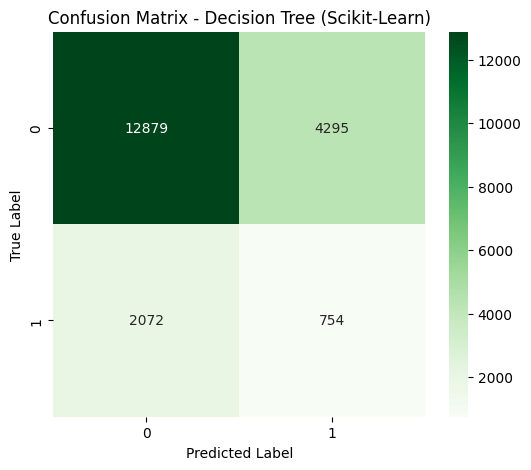

In [377]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Training DTL (Scikit-Learn)")

if 'X_train_final' in locals() and 'y_train_final' in locals():
    X_train_dt = X_train_final
    y_train_dt = y_train_final
    X_val_dt = X_val_final
    y_val_dt = y_val_final
else:
    if 'X_train_np' in locals():
        X_train_dt = X_train_np
        y_train_dt = y_train_np
        X_val_dt = X_val_np
        y_val_dt = y_val_np
    else:
        raise ValueError("Data Training tidak ditemukan! Pastikan Section 3 (Preprocessing) sudah dijalankan.")

print(f"Menggunakan data training shape: {X_train_dt.shape}")
print(f"Menggunakan data validasi shape: {X_val_dt.shape}")

# criterion bisa 'entropy' atau 'gini'
dt_model_sk = DecisionTreeClassifier(criterion='gini', random_state=42)

dt_model_sk.fit(X_train_dt, y_train_dt)

y_pred_dt = dt_model_sk.predict(X_val_dt)
y_prob_dt = dt_model_sk.predict_proba(X_val_dt)[:, 1] 

evaluate_model_dtl(y_val_dt, y_pred_dt, y_prob_dt, "Decision Tree (Scikit-Learn)")

## B. Logistic Regression

In [378]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, average_precision_score, 
                             classification_report, confusion_matrix)

def evaluate_model(y_true, y_pred, y_prob, model_name):
    print(f"\n{'='*20} Evaluasi: {model_name} {'='*20}")
    
    # Hitung Metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')
    f1 = f1_score(y_true, y_pred, average='macro')
    
    # Handling ROC AUC
    try:
        roc = roc_auc_score(y_true, y_prob)
    except:
        roc = 0

    print(f"=== Model Evaluation Metrics (threshold=0.5) ===")
    print(f"{'Accuracy':<20} : {acc:.4f}")
    print(f"{'Precision (Macro)':<20} : {prec:.4f}")
    print(f"{'Recall (Macro)':<20} : {rec:.4f}")
    print(f"{'F1 Score (Macro)':<20} : {f1:.4f}")
    print(f"{'ROC AUC Score':<20} : {roc:.4f}")
    
    print(f"\n=== Detailed Classification Report ===")
    print(classification_report(y_true, y_pred))
    
    # Plot Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=True)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()

In [379]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


# data Training
if 'X_train_np' in locals() and 'y_train_np' in locals():
    X_train_fix = X_train_np
    y_train_fix = y_train_np
elif 'X_train_res' in locals() and 'y_train_res' in locals():
    X_train_fix = X_train_res
    y_train_fix = y_train_res
else:
    raise ValueError("Data Training tidak ditemukan! Pastikan Anda sudah menjalankan Cell 'Persiapan Data' & 'SMOTE' sebelumnya.")


# data Validasi
if 'X_val_np' in locals() and 'y_val_np' in locals():
    X_test_fix = X_val_np
    y_test_fix = y_val_np
elif 'X_val_split' in locals() and 'y_val_split' in locals():
    X_test_fix = X_val_split
    y_test_fix = y_val_split
else:
    raise ValueError("Data Validasi tidak ditemukan! Pastikan cell Split Data sudah dijalankan.")


print(f"Menggunakan data training shape: {X_train_fix.shape}")
print(f"Menggunakan data validasi shape: {X_test_fix.shape}")


model_sk = LogisticRegression(max_iter=1000, random_state=42)


# Training
model_sk.fit(X_train_fix, y_train_fix)


# Prediksi data validasi
y_pred_sk = model_sk.predict(X_test_fix)


# Eval
accuracy = accuracy_score(y_test_fix, y_pred_sk)
print(f"\nAkurasi (Scikit-learn): {accuracy * 100:.2f}%")
print("\nReport Klasifikasi:")
print(classification_report(y_test_fix, y_pred_sk))



Menggunakan data training shape: (134638, 33)
Menggunakan data validasi shape: (19601, 33)

Akurasi (Scikit-learn): 60.10%

Report Klasifikasi:
              precision    recall  f1-score   support

           0       0.88      0.62      0.73     16831
           1       0.18      0.51      0.27      2770

    accuracy                           0.60     19601
   macro avg       0.53      0.56      0.50     19601
weighted avg       0.78      0.60      0.66     19601



In [380]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = 0
        self.cost_history = []


    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))


    def cost(self, h, y):
        m = len(y)
        epsilon = 1e-15
        h = np.clip(h, epsilon, 1 - epsilon)
        return - (1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h))


    def fit(self, X, y):
        m, n = X.shape
        self.weights = np.zeros(n)
        self.bias = 0
       
        for i in range(self.iterations):
            z = np.dot(X, self.weights) + self.bias
            h = self.sigmoid(z)


            dw = (1/m) * np.dot(X.T, (h - y))
            db = (1/m) * np.sum(h - y)


            self.weights -= self.lr * dw
            self.bias -= self.lr * db
           
            if i % 100 == 0:
                self.cost_history.append(self.cost(h, y))


    def predict_proba(self, X):
        """ngembaliin nilai probabilitas (0.0 s/d 1.0)"""
        z = np.dot(X, self.weights) + self.bias
        return self.sigmoid(z)


    def predict(self, X):
        """Ngembaliin nilai hasil (0 atau 1)"""
        return (self.predict_proba(X) >= 0.5).astype(int)



## C. KNN

In [381]:
# Type your code here

## D. Improvements (Optional)

- **Visualize the model evaluation result**

This will help you to understand the details more clearly about your model's performance. From the visualization, you can see clearly if your model is leaning towards a class than the others. (Hint: confusion matrix, ROC-AUC curve, etc.)

- **Explore the hyperparameters of your models**

Each models have their own hyperparameters. And each of the hyperparameter have different effects on the model behaviour. You can optimize the model performance by finding the good set of hyperparameters through a process called **hyperparameter tuning**. (Hint: Grid search, random search, bayesian optimization)

- **Cross-validation**

Cross-validation is a critical technique in machine learning and data science for evaluating and validating the performance of predictive models. It provides a more **robust** and **reliable** evaluation method compared to a hold-out (single train-test set) validation. Though, it requires more time and computing power because of how cross-validation works. (Hint: k-fold cross-validation, stratified k-fold cross-validation, etc.)

In [382]:
# Type your code here

## E. Submission
To predict the test set target feature and submit the results to the kaggle competition platform, do the following:
1. Create a new pipeline instance identical to the first in Data Preprocessing
2. With the pipeline, apply `fit_transform` to the original training set before splitting, then only apply `transform` to the test set.
3. Retrain the model on the preprocessed training set
4. Predict the test set
5. Make sure the submission contains the `id` and `attack_cat` column.

Training DTL (Scratch)
Mengambil 1000 data acak (total 137396 data)
Data siap! Shape X: (1000, 21), Shape y: (1000,)

lagi latihan...
Depth: 0, Processing 1000 samples


Depth: 1, Processing 801 samples
Depth: 2, Processing 85 samples
Depth: 3, Processing 59 samples
Depth: 4, Processing 25 samples
Depth: 5, Processing 10 samples
Depth: 5, Processing 15 samples
Depth: 4, Processing 34 samples
Depth: 5, Processing 33 samples
Depth: 5, Processing 1 samples
Depth: 3, Processing 26 samples
Depth: 4, Processing 4 samples
Depth: 4, Processing 22 samples
Depth: 5, Processing 16 samples
Depth: 5, Processing 6 samples
Depth: 2, Processing 716 samples
Depth: 3, Processing 155 samples
Depth: 4, Processing 141 samples
Depth: 5, Processing 115 samples
Depth: 5, Processing 26 samples
Depth: 4, Processing 14 samples
Depth: 5, Processing 13 samples
Depth: 5, Processing 1 samples
Depth: 3, Processing 561 samples
Depth: 4, Processing 97 samples
Depth: 5, Processing 62 samples
Depth: 5, Processing 35 samples
Depth: 4, Processing 464 samples
Depth: 5, Processing 82 samples
Depth: 5, Processing 382 samples
Depth: 1, Processing 199 samples
Depth: 2, Processing 179 samples
De

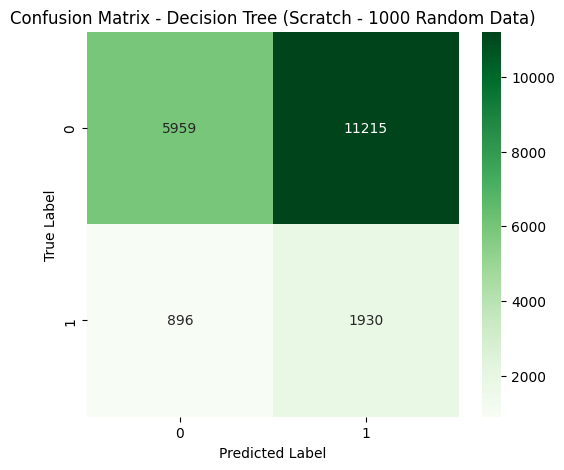

In [383]:
import time
print("Training DTL (Scratch)")

if isinstance(X_train_final, np.ndarray):
    X_train_scratch = pd.DataFrame(X_train_final)
    X_train_scratch.columns = X_train_scratch.columns.astype(str) # jadi str
    
    y_train_scratch = pd.Series(y_train_final)
    
    X_val_scratch = pd.DataFrame(X_val_final)
    X_val_scratch.columns = X_val_scratch.columns.astype(str) # jadi str
    
    y_val_scratch = pd.Series(y_val_final)
else:
    X_train_scratch = X_train_final.copy()
    X_train_scratch.columns = X_train_scratch.columns.astype(str)
    y_train_scratch = y_train_final.copy()
    X_val_scratch = X_val_final.copy()
    X_val_scratch.columns = X_val_scratch.columns.astype(str)
    y_val_scratch = y_val_final.copy()

jumlah_data_latih = 1000  

print(f"Mengambil {jumlah_data_latih} data acak (total {len(X_train_scratch)} data)")

train_temp = X_train_scratch.copy()
train_temp['__target_temp__'] = y_train_scratch.values 

#sampling
train_sampled = train_temp.sample(n=jumlah_data_latih, random_state=42)

X_train_part = train_sampled.drop(columns=['__target_temp__'])
y_train_part = train_sampled['__target_temp__']

print(f"Data siap! Shape X: {X_train_part.shape}, Shape y: {y_train_part.shape}")

dt_model_scratch = DecisionTreeCART(max_depth=5, min_samples=10) 

start_time = time.time()
print("\nlagi latihan...")

# Training
dt_model_scratch.fit(X_train_part, y_train_part)

print(f"Training selesai dalam {time.time() - start_time:.2f} detik.")

# Evaluasi
print("prediksi")
y_pred_scratch = dt_model_scratch.predict(X_val_scratch)
y_prob_scratch = y_pred_scratch 

evaluate_model_dtl(y_val_scratch, y_pred_scratch, y_prob_scratch, f"Decision Tree (Scratch - {jumlah_data_latih} Random Data)")

In [ ]:
print("submission")

if isinstance(X_test_kaggle, np.ndarray):
    X_test_kaggle_df = pd.DataFrame(X_test_kaggle)
else:
    X_test_kaggle_df = pd.DataFrame(X_test_kaggle.values)

X_test_kaggle_df.columns = [str(i) for i in range(X_test_kaggle_df.shape[1])]

print(f"Shape test: {X_test_kaggle_df.shape}")

print("lagi predik")
y_pred_final = dt_model_scratch.predict(X_test_kaggle_df)

# Simpan
submission = pd.DataFrame({
    'ID': submission_id,
    'is_fraud': y_pred_final
})

submission['is_fraud'] = submission['is_fraud'].astype(int)
submission.to_csv('submission.csv', index=False)

print("\nfile 'submission_DTL.csv' BERHASIL dibuat!")
print(submission.head())

buat file submission
Shape test: (100000, 33)
Contoh kolom: ['0', '1', '2', '3', '4']
Sedang memprediksi data test... (Mohon tunggu, ini butuh waktu)

file 'submission.csv' BERHASIL dibuat!
   ID  is_fraud
0   0         1
1   1         0
2   2         1
3   3         0
4   4         1


In [385]:
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from imblearn.over_sampling import SMOTE

# print("submisi logreg")

# # Load Data
# train_df = pd.read_csv('train.csv')
# test_df = pd.read_csv('test.csv')
# submission_id = test_df['ID']  

# # leaning Pipeline
# train_df = impute_missing_values(train_df)
# train_df = clip_outliers(train_df)
# train_df = remove_duplicates(train_df)
# train_df = create_features(train_df)

# test_df = impute_missing_values(test_df)
# test_df = clip_outliers(test_df) 
# test_df = create_features(test_df)

# # Feature Selection & Encoding
# target_col = 'is_fraud'
# drop_cols = ['ID', 'transaction_id', 'user_id', 'transaction_type', 'transaction_duration'] 

# X = train_df.drop(columns=[target_col], errors='ignore')
# y = train_df[target_col]
# X_test_kaggle = test_df.copy()

# cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
# num_cols = X.select_dtypes(include=['number']).columns.tolist()
# cat_cols = [c for c in cat_cols if c not in drop_cols]
# num_cols = [c for c in num_cols if c not in drop_cols]

# # transformation
# dropper = ColumnDropper(cols_to_drop=drop_cols)
# X = dropper.transform(X)
# X_test_kaggle = dropper.transform(X_test_kaggle)

# encoder = FeatureEncoder(cols_to_encode=cat_cols, encoding_type='label') 
# encoder.fit(X, y)
# X = encoder.transform(X)
# X_test_kaggle = encoder.transform(X_test_kaggle)

# scaler = FeatureScaler(cols_to_scale=num_cols, scaler_type='standard')
# scaler.fit(X)
# X = scaler.transform(X)
# X_test_kaggle = scaler.transform(X_test_kaggle)

# print("data selesai")

In [386]:
# print("Training & eval")

# # Split Data 
# X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y # 20 persen
# )

# # Handle Imbalance (SMOTE)
# smote = SMOTE(random_state=42)
# X_train_res, y_train_res = smote.fit_resample(X_train_split, y_train_split)

# # ubah ke Numpy 
# X_train_np = X_train_res.values
# y_train_np = y_train_res.values
# X_val_np = X_val_split.values
# y_val_np = y_val_split.values

# print("latih logreg scratch")
# model_submission = LogisticRegressionScratch(learning_rate=0.1, iterations=2000)
# model_submission.fit(X_train_np, y_train_np)

# # E. Evaluasi
# y_pred_val = model_submission.predict(X_val_np)
# y_prob_val = model_submission.predict_proba(X_val_np)

# evaluate_model(y_val_np, y_pred_val, y_prob_val, "Logistic Regression Scratch (Validation)")

In [387]:
# print("buat file")

# X_test_kaggle_np = X_test_kaggle.values
# y_pred_final = model_submission.predict(X_test_kaggle_np)

# # Simpan
# submission = pd.DataFrame({
#     'ID': submission_id,
#     'is_fraud': y_pred_final
# })

# submission['is_fraud'] = submission['is_fraud'].astype(int)
# submission.to_csv('submission.csv', index=False)

# print("\nfile 'submission.csv' dah ada")
# print(submission.head())

# 6. Error Analysis

Based on all the process you have done until the modeling and evaluation step, write an analysis to support each steps you have taken to solve this problem. Write the analysis using the markdown block. Some questions that may help you in writing the analysis:

- Does my model perform better in predicting one class than the other? If so, why is that?
- To each models I have tried, which performs the best and what could be the reason?
- Is it better for me to impute or drop the missing data? Why?
- Does feature scaling help improve my model performance?
- etc...

`Provide your analysis here`

In [388]:
# Imputer DataFrame: median untuk numerik, modus/"Unknown" untuk kategorikal
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd

class DataFrameImputer(BaseEstimator, TransformerMixin):
    def __init__(self, unknown_fill="Unknown"):
        self.unknown_fill = unknown_fill
        self.num_medians_ = {}
        self.cat_modes_ = {}
        self.num_cols_ = []
        self.cat_cols_ = []

    def fit(self, X, y=None):
        df = X.copy()
        self.num_cols_ = df.select_dtypes(include=['number']).columns.tolist()
        self.cat_cols_ = df.select_dtypes(exclude=['number']).columns.tolist()
        for c in self.num_cols_:
            self.num_medians_[c] = df[c].median()
        for c in self.cat_cols_:
            mode_series = df[c].mode(dropna=True)
            self.cat_modes_[c] = mode_series.iloc[0] if not mode_series.empty else self.unknown_fill
        return self

    def transform(self, X):
        df = X.copy()
        for c in self.num_cols_:
            if c in df.columns:
                df[c] = df[c].fillna(self.num_medians_[c])
        for c in self.cat_cols_:
            if c in df.columns:
                df[c] = df[c].fillna(self.cat_modes_[c])
        return df

In [389]:
# Error Analysis – Evaluasi di Validation (aman, tanpa menyentuh submission)
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report

# Asumsi variabel berikut sudah tersedia dari bagian Modeling & Validation:
# X_val_preprocessed (numpy.ndarray), y_val_final (Series/array), model (sudah terlatih)

if 'X_val_preprocessed' in globals() and 'y_val_final' in globals() and 'model' in globals():
    if hasattr(model, 'predict') and callable(model.predict):
        y_val_pred = model.predict(X_val_preprocessed)
    elif hasattr(model, 'predict_proba') and callable(model.predict_proba):
        y_val_pred = (model.predict_proba(X_val_preprocessed)[:, 1] >= 0.5).astype(int)
    else:
        raise RuntimeError('Model tidak memiliki method predict/predict_proba yang dapat dipanggil.')

    cm = confusion_matrix(y_val_final, y_val_pred)
    print('Confusion Matrix (Validation):')
    print(cm)

    print('\nClassification Report (Validation):')
    print(classification_report(y_val_final, y_val_pred, digits=4))
else:
    print('Variabel yang dibutuhkan untuk Error Analysis belum tersedia. Pastikan Modeling & Validation sudah dijalankan.')

Variabel yang dibutuhkan untuk Error Analysis belum tersedia. Pastikan Modeling & Validation sudah dijalankan.
